# Exercício:

## 01 – Usando o método np.random.normal(), gere valores de expressão gênica de um conjunto de 1.000 genes. Esse conjunto de ter valores up e downregulated.

In [1]:
import numpy as np
import pandas as pd

expressao = np.random.normal(loc=0, scale=1.5, size=1000)

df_genes = pd.DataFrame({
    'Gene_ID': [f'Gene_{i}' for i in range(1, 1001)],
    'Expressao_LFC': expressao
})

print(f"Total de genes up-regulated: {(df_genes['Expressao_LFC'] > 0).sum()}")
print(f"Total de genes down-regulated: {(df_genes['Expressao_LFC'] < 0).sum()}")

display(df_genes.head())

Total de genes up-regulated: 505
Total de genes down-regulated: 495


,Gene_ID,Expressao_LFC
0,Gene_1,0.382650
1,Gene_2,1.918648
2,Gene_3,0.946971
3,Gene_4,-1.508806
4,Gene_5,-0.136435


## 02 – Usando o método np.random.randint(), gere valores para o número de genes diferencialmente expressos em um conjunto de 1.000 pacientes. Esse conjunto deve ter valores up e downregulated.

Instancie um objeto da classe DataFrame, com os dados gerados nos dois exercícios.

In [2]:
lfc_pacientes = np.random.randint(-10, 11, size=1000)

df_pacientes = pd.DataFrame({
    'Paciente_ID': [f'Paciente_{i}' for i in range(1, 1001)],
    'Genes_Diferenciais': lfc_pacientes
})

print(f"Pacientes com genes Up-regulated: {(df_pacientes['Genes_Diferenciais'] > 0).sum()}")
print(f"Pacientes com genes Down-regulated: {(df_pacientes['Genes_Diferenciais'] < 0).sum()}")
display(df_pacientes.head())

Pacientes com genes Up-regulated: 493
Pacientes com genes Down-regulated: 453


,Paciente_ID,Genes_Diferenciais
0,Paciente_1,7
1,Paciente_2,-10
2,Paciente_3,5
3,Paciente_4,8
4,Paciente_5,-7


## 03 – Categorize em grupos de 6 os dados contidos na DataFrame anterior, segundo critérios escolhidos por você. Explique os critérios.

Os genes foram divididos em 6 grupos a seguir de acordo com a expressão deles

- Altamente Downregulated: Valores de -10 a -7.

- Moderadamente Downregulated: Valores de -6 a -3.

- Levemente Downregulated: Valores de -2 a -1.

- Levemente Upregulated: Valores de 1 a 2.

- Moderadamente Upregulated: Valores de 3 a 6.

- Altamente Upregulated: Valores de 7 a 10.

In [3]:
intervalos = [-11, -7, -3, 0, 3, 7, 11]
rotulos = [
    'Altamente Downregulated', 
    'Moderadamente Downregulated', 
    'Levemente Downregulated', 
    'Levemente Upregulated', 
    'Moderadamente Upregulated', 
    'Altamente Upregulated'
]

df_pacientes['Categoria'] = pd.cut(
    df_pacientes['Genes_Diferenciais'], 
    bins=intervalos, 
    labels=rotulos
)

print(df_pacientes['Categoria'].value_counts().sort_index())
display(df_pacientes.head(10))

Categoria
Altamente Downregulated        178
Moderadamente Downregulated    186
Levemente Downregulated        143
Levemente Upregulated          154
Moderadamente Upregulated      192
Altamente Upregulated          147
Name: count, dtype: int64


,Paciente_ID,Genes_Diferenciais,Categoria
0,Paciente_1,7,Moderadamente Upregulated
1,Paciente_2,-10,Altamente Downregulated
2,Paciente_3,5,Moderadamente Upregulated
3,Paciente_4,8,Altamente Upregulated
4,Paciente_5,-7,Altamente Downregulated
5,Paciente_6,0,Levemente Downregulated
6,Paciente_7,3,Levemente Upregulated
7,Paciente_8,9,Altamente Upregulated
8,Paciente_9,-10,Altamente Downregulated
9,Paciente_10,-7,Altamente Downregulated


## 04 – Defina uma função em Python que receba uma pd.Series contendo uma variável quantitativa e retorne uma DataFrame contendo a tabela de frequência.

Obtenha a tabela de frequência das variáveis criadas nos exercícios 1 e 2.

In [4]:
import pandas as pd

def gerar_tabela_frequencia(series):
    frequencia_absoluta = series.value_counts()
    frequencia_relativa = series.value_counts(normalize=True)
    
    tabela = pd.DataFrame({
        'Frequência Absoluta': frequencia_absoluta,
        'Frequência Relativa (%)': frequencia_relativa * 100
    })
    
    return tabela.sort_index()

tabela_ex1 = gerar_tabela_frequencia(df_genes['Expressao_LFC'])
tabela_ex2 = gerar_tabela_frequencia(df_pacientes['Genes_Diferenciais'])

print("Tabela de Frequência - Exercício 1 (Primeiras 5 linhas):")
display(tabela_ex1.head())

print("\nTabela de Frequência - Exercício 2 (Primeiras 5 linhas):")
display(tabela_ex2.head())


Tabela de Frequência - Exercício 1 (Primeiras 5 linhas):


,Frequência Absoluta,Frequência Relativa (%)
Expressao_LFC,,
-4.133801,1,0.1
-4.117538,1,0.1
-4.005354,1,0.1
-3.972981,1,0.1
-3.953947,1,0.1



Tabela de Frequência - Exercício 2 (Primeiras 5 linhas):


,Frequência Absoluta,Frequência Relativa (%)
Genes_Diferenciais,,
-10,46,4.6
-9,41,4.1
-8,48,4.8
-7,43,4.3
-6,47,4.7


## 05 – Gere os gráficos de barras e linhas para as frequências em cada umas das variáveis.

### Expressão

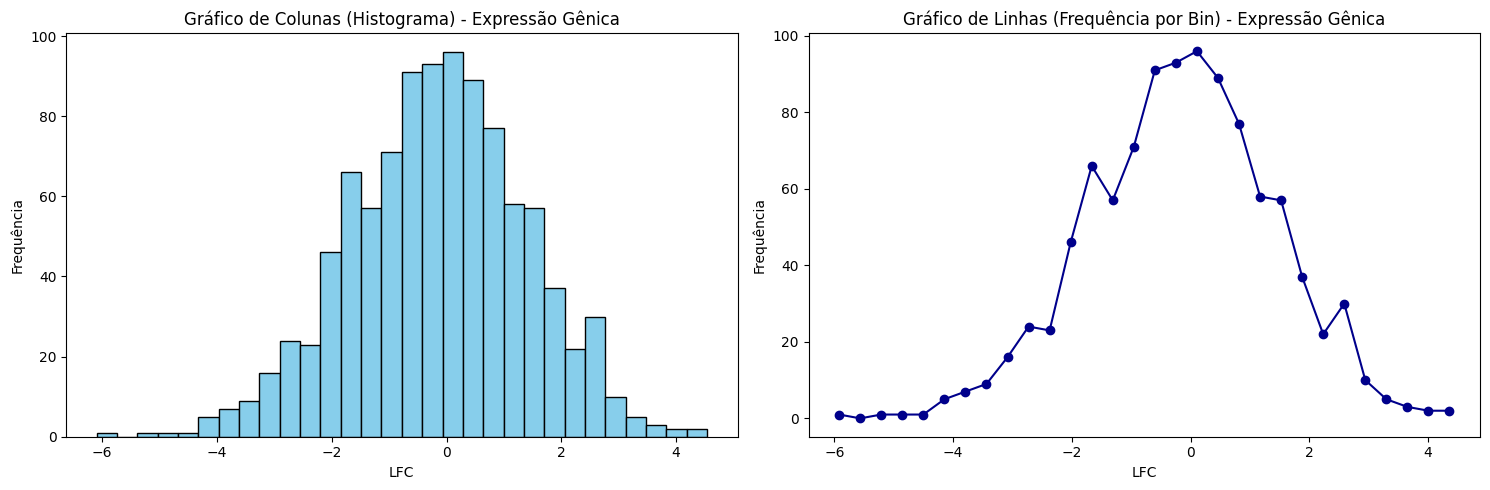

In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

expressao = np.random.normal(loc=0, scale=1.5, size=1000)
df_genes = pd.DataFrame({
    'Gene_ID': [f'Gene_{i}' for i in range(1, 1001)],
    'Expressao_LFC': expressao
})

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df_genes['Expressao_LFC'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Gráfico de Colunas (Histograma) - Expressão Gênica')
ax1.set_xlabel('LFC')
ax1.set_ylabel('Frequência')

counts, bins = np.histogram(df_genes['Expressao_LFC'], bins=30)
bin_centers = (bins[:-1] + bins[1:]) / 2
ax2.plot(bin_centers, counts, marker='o', linestyle='-', color='darkblue')
ax2.set_title('Gráfico de Linhas (Frequência por Bin) - Expressão Gênica')
ax2.set_xlabel('LFC')
ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

### Número

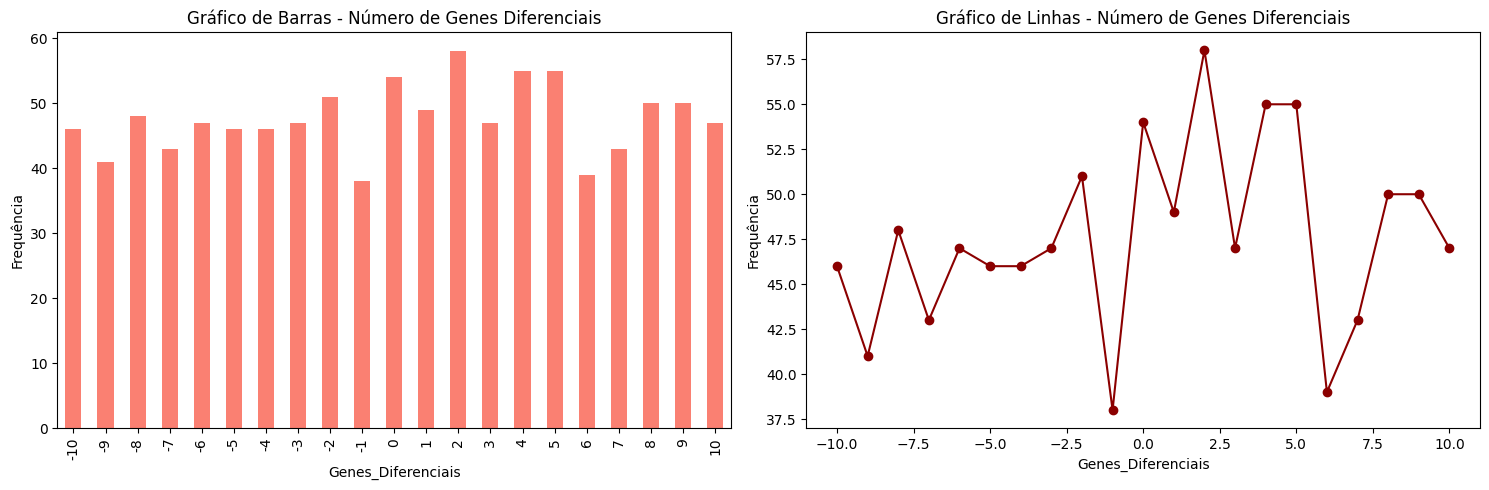

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

tabela_ex2['Frequência Absoluta'].plot(kind='bar', ax=ax1, color='salmon')
ax1.set_title('Gráfico de Barras - Número de Genes Diferenciais')
ax1.set_ylabel('Frequência')

tabela_ex2['Frequência Absoluta'].plot(kind='line', ax=ax2, marker='o', color='darkred')
ax2.set_title('Gráfico de Linhas - Número de Genes Diferenciais')
ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()


## 06 – Gere os histogramas para as variáveis obtidas nos exercícios 1 e 2.

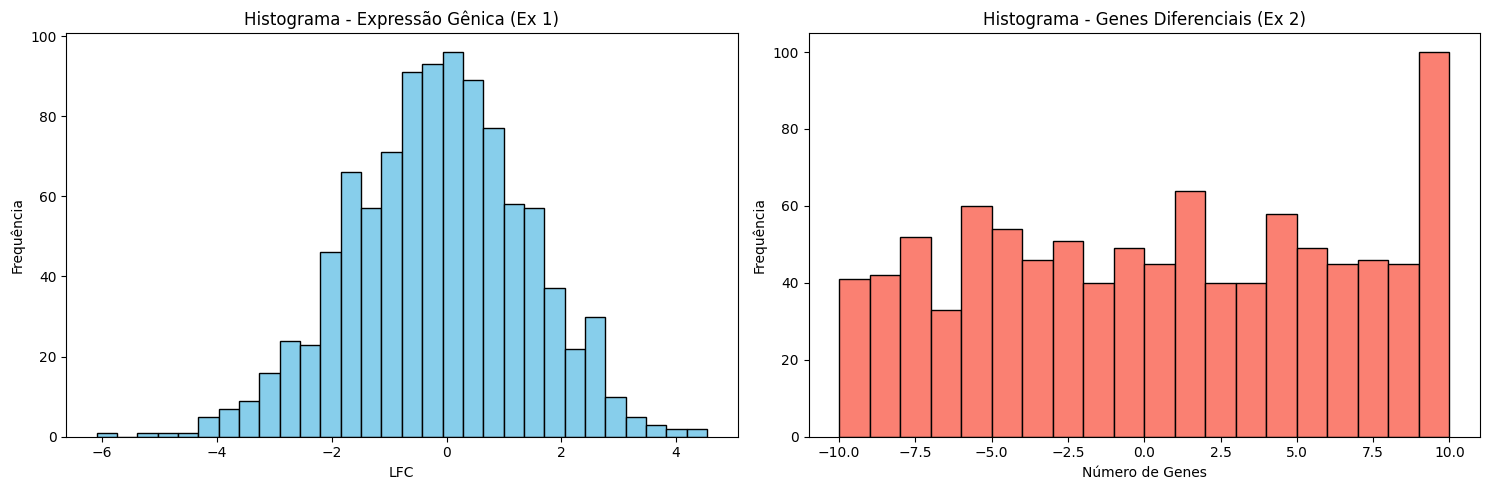

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.hist(df_genes['Expressao_LFC'], bins=30, color='skyblue', edgecolor='black')
ax1.set_title('Histograma - Expressão Gênica (Ex 1)')
ax1.set_xlabel('LFC')
ax1.set_ylabel('Frequência')

ax2.hist(df_pacientes['Genes_Diferenciais'], bins=20, color='salmon', edgecolor='black')
ax2.set_title('Histograma - Genes Diferenciais (Ex 2)')
ax2.set_xlabel('Número de Genes')
ax2.set_ylabel('Frequência')

plt.tight_layout()
plt.show()

## 07 – Gere um gráfico de dispersão para as variáveis obtidas nos exercícios 1 e 2.

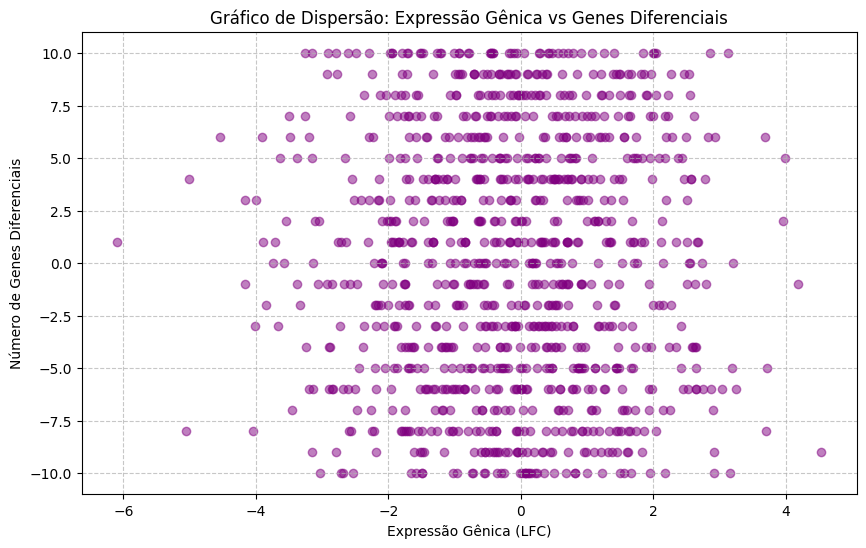

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(df_genes['Expressao_LFC'], df_pacientes['Genes_Diferenciais'], alpha=0.5, color='purple')

plt.title('Gráfico de Dispersão: Expressão Gênica vs Genes Diferenciais')
plt.xlabel('Expressão Gênica (LFC)')
plt.ylabel('Número de Genes Diferenciais')
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

## 08 – Gere o mesmo gráfico do exercício 06, porém, categorizado.

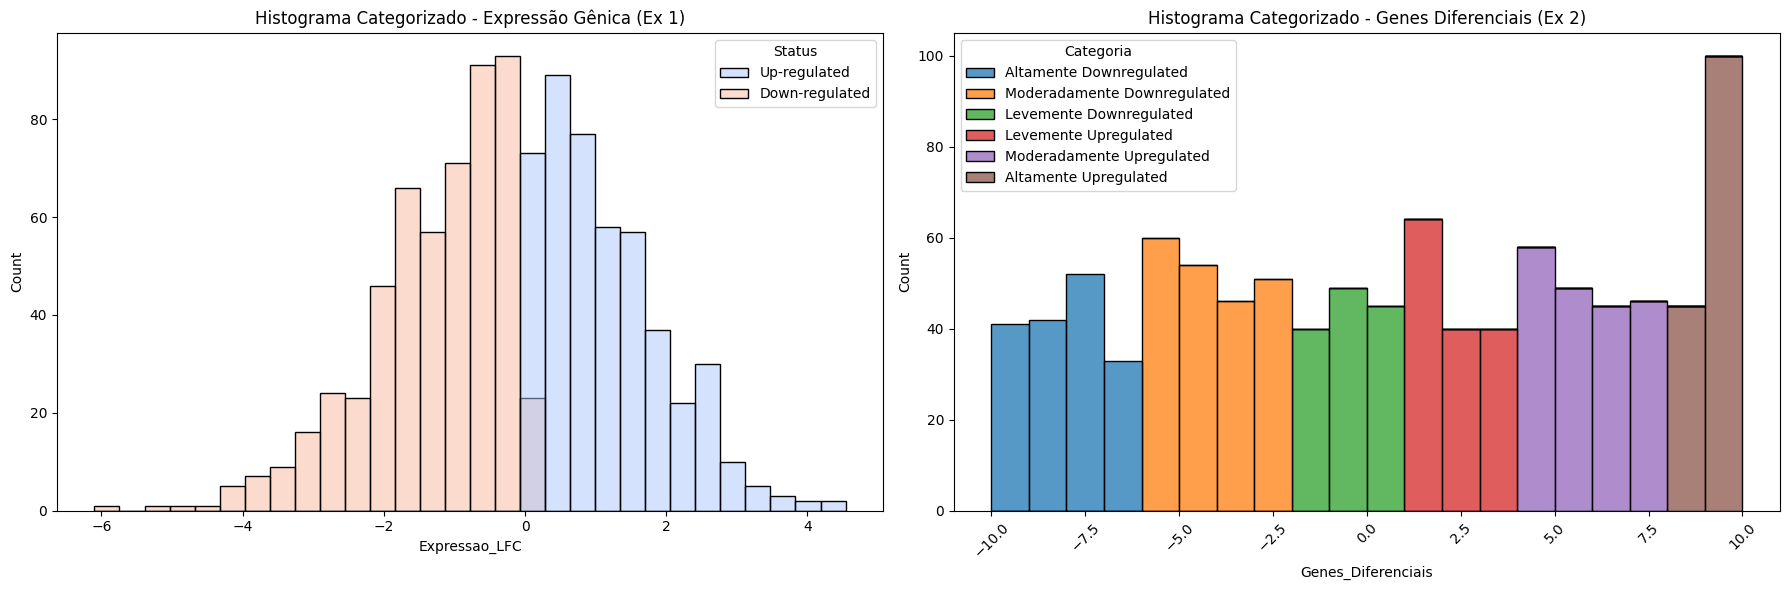

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

df_genes['Status'] = df_genes['Expressao_LFC'].apply(lambda x: 'Up-regulated' if x > 0 else 'Down-regulated')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(data=df_genes, x='Expressao_LFC', hue='Status', bins=30, ax=ax1, palette='coolwarm')
ax1.set_title('Histograma Categorizado - Expressão Gênica (Ex 1)')

sns.histplot(data=df_pacientes, x='Genes_Diferenciais', hue='Categoria', bins=20, ax=ax2, multiple='stack')
ax2.set_title('Histograma Categorizado - Genes Diferenciais (Ex 2)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 09 – Gere o mesmo gráfico do exercício 07, porém, categorizado.

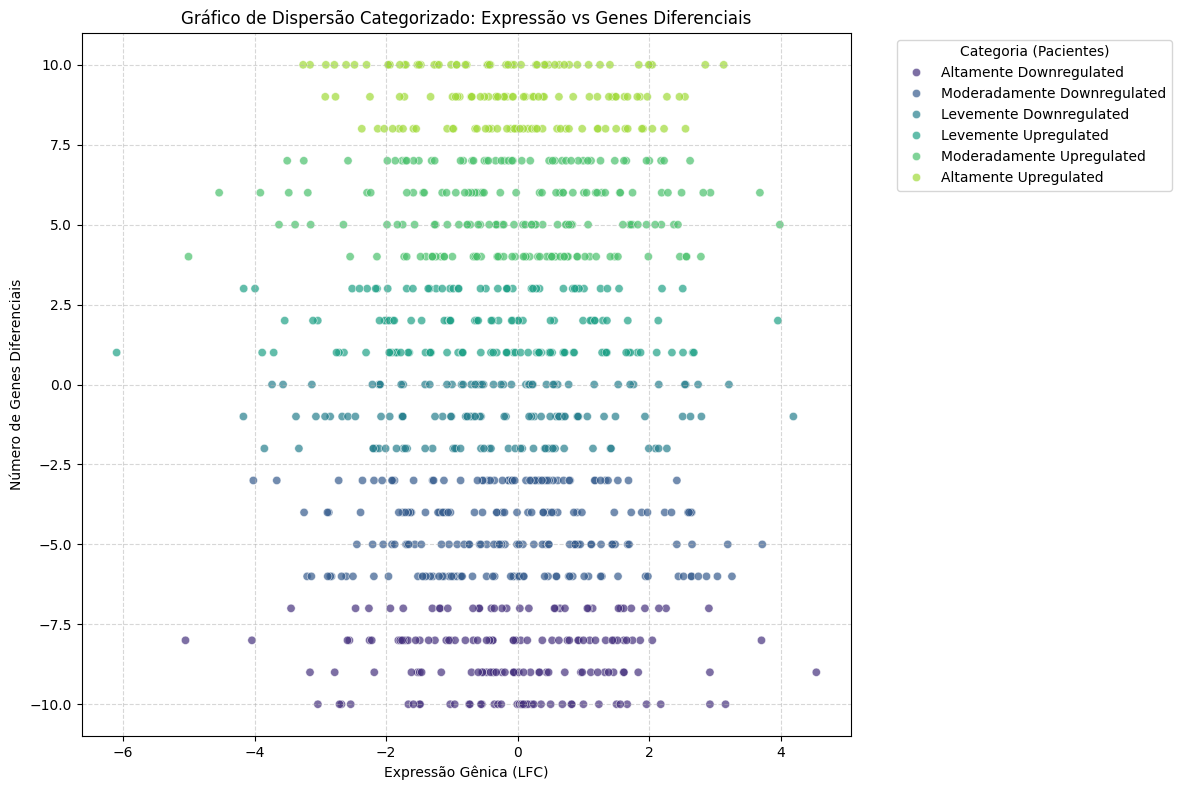

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

df_merged = pd.concat([df_genes, df_pacientes], axis=1)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_merged, 
    x='Expressao_LFC', 
    y='Genes_Diferenciais', 
    hue='Categoria', 
    palette='viridis', 
    alpha=0.7
)

plt.title('Gráfico de Dispersão Categorizado: Expressão vs Genes Diferenciais')
plt.xlabel('Expressão Gênica (LFC)')
plt.ylabel('Número de Genes Diferenciais')
plt.legend(title='Categoria (Pacientes)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 10 – Indique o tipo da variável:

- Discreta
- Contínua
- Ordinal
- Nominal

| Variável | Valor |
| :--- | :---: |
| # de células positivas|discrte|
| % de células positivas|continua|
| Faixa de pH|ordinal|
| Valor de pH|continua|
| mol/L|continua|
| UFC|discreta|
| D.O.|continua|
| Grupo Sanguíneo|nominal|
| Sorologia|nominal|